# Problem Title - Final Best model with benchmark and error breakdown
Issue: #1

-Cement
-Superplasticizer
-Age
-Water
-FineAggregate

In [93]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [94]:
df = pd.read_csv('../dataset.csv')

In [95]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Concrete compressive strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [96]:
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [97]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [98]:
y=df[['Concrete compressive strength']]
X=df[['Cement','Superplasticizer'
,'Age'
,'Water'
,'Fine Aggregate']]

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 50, 100]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error"
)
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print("Best Alpha:", grid.best_params_)

Best Alpha: {'ridge__alpha': 10}


In [101]:
models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge Regression"   : Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])
}

In [102]:
results = {}

In [103]:
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    results[name] =  {
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mse,
        "Predictions": y_pred
        }
    

In [104]:
results_df = pd.DataFrame(results).T
print(results_df[["RMSE", "R2", "MAE", "MSE"]])

                       RMSE        R2       MAE        MSE
Linear Regression  9.944097  0.616244  7.997558  98.885072
Ridge Regression   9.945498  0.616136  7.999599  98.912933


In [105]:
def stratified_mae(y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    
    df_temp = pd.DataFrame({"y": y_true, "pred": y_pred})
    df_temp = df_temp.sort_values("y")
    
    n = len(df_temp)
    
    bottom = df_temp[:n//3]
    middle = df_temp[n//3: 2*n//3]
    top = df_temp[2*n//3:]
    
    return {
        "Bottom 33%": mean_absolute_error(bottom["y"], bottom["pred"]),
        "Middle 33%": mean_absolute_error(middle["y"], middle["pred"]),
        "Top 33%": mean_absolute_error(top["y"], top["pred"]),
    }

In [106]:
ridge_pred = results["Ridge Regression"]["Predictions"]

stratified = stratified_mae(y_test, ridge_pred)


for k, v in stratified.items():
    print(f"{k}: {v:.4f}")

Bottom 33%: 8.0530
Middle 33%: 6.0137
Top 33%: 9.9329


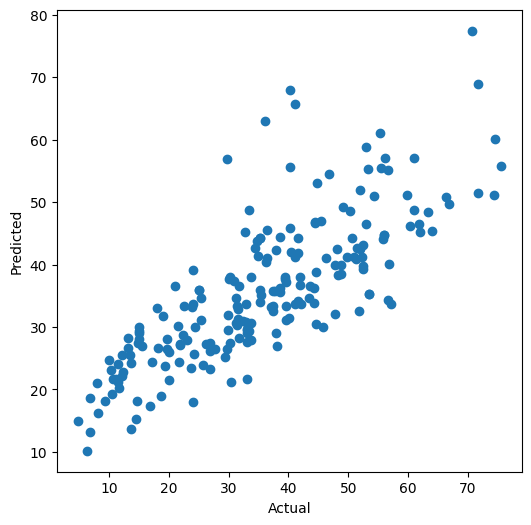

In [107]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, ridge_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

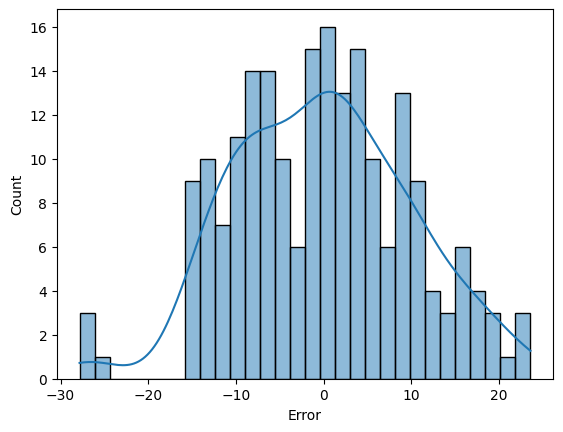

In [91]:
errors = y_test.values.ravel() - ridge_pred.ravel()

sns.histplot(errors, bins=30, kde=True)
plt.xlabel("Error")
plt.show()

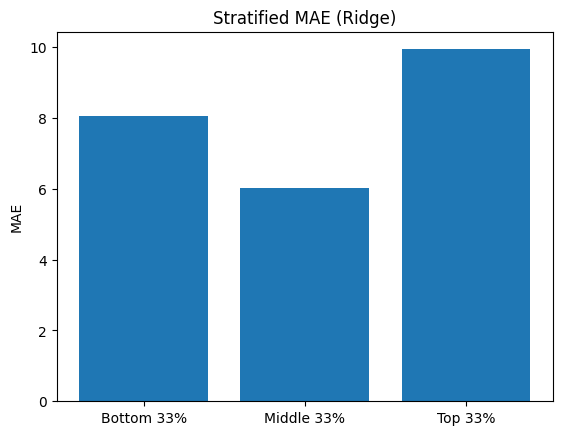

In [92]:
plt.bar(stratified.keys(), stratified.values())
plt.title("Stratified MAE (Ridge)")
plt.ylabel("MAE")
plt.show()

## Insights
1.Lower error in middle range values
2.Higher error in top 33% (high strength concrete)
3.Indicates limitation of linear assumptions